In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

# Load all CSV files from the data folder in one cell
data_dir = Path("data")

employees = pd.read_csv(data_dir / "BOLT_Employees.csv")
changes = pd.read_csv(data_dir / "BOLT_EmployeeChanges.csv")
performance = pd.read_csv(data_dir / "BOLT_Performance.csv")
applicants = pd.read_csv(data_dir / "BOLT_Applicants.csv")
branch = pd.read_csv(data_dir / "BOLT_Branch.csv")

# Parse date columns
if "HiredOn" in employees.columns:
    employees["HiredOn"] = pd.to_datetime(employees["HiredOn"], errors="coerce")

if "DateChanged" in changes.columns:
    changes["DateChanged"] = pd.to_datetime(changes["DateChanged"], errors="coerce")

if "DateReviewed" in performance.columns:
    performance["DateReviewed"] = pd.to_datetime(performance["DateReviewed"], errors="coerce")

if "DatePosted" in branch.columns:
    branch["DatePosted"] = pd.to_datetime(branch["DatePosted"], errors="coerce")

print("Loaded shapes:")
print("employees:", employees.shape)
print("changes:", changes.shape)
print("performance:", performance.shape)
print("applicants:", applicants.shape)
print("branch:", branch.shape)

display(employees.head())
display(changes.head())
display(performance.head())
display(applicants.head())
display(branch.head())

Loaded shapes:
employees: (1067, 9)
changes: (1165, 4)
performance: (2189, 3)
applicants: (10500, 6)
branch: (1049, 7)


,EmployeeID,Wage,HiredOn,Branch#,Current status,Position,Role,AvgWorkingHours/Week,ApplicantID
0,5764,Minimum,2022-06-13,1,Working,full-time,Manager,48.8,107642
1,5997,Minimum,2024-02-26,1,Working,full-time,Manager,50.4,109966
2,5454,Competitive,2024-06-20,1,Working,full-time,Manager,49.2,104693
3,5557,Competitive,2024-09-04,1,Working,full-time,Manager,52.0,105628
4,5923,Minimum,2024-12-07,1,Working,full-time,Manager,48.6,109352


,EmployeeID,New Role,DateChanged,ReasonForLeaving
0,5000,Quit,2024-10-07,Poor Management
1,5001,Quit,2025-02-01,Better Offer
2,5002,Quit,2022-06-25,Lack of Growth
3,5003,Quit,2025-11-05,Poor Management
4,5005,Quit,2025-03-21,Lack of Growth


,EmployeeID,DateReviewed,PerformanceScore
0,5764,2022-09-11,88.22
1,5764,2022-12-10,88.86
2,5764,2023-03-10,87.28
3,5764,2023-06-08,91.00
4,5764,2023-09-06,92.23


,ApplicantID,PastRelevantExperience,YearsOfRelevantExperience,HighestEducationLevel,YearOfBirth,Hired
0,100000,True,2,High School,2003,False
1,100001,True,2,Bachelor,2002,True
2,100002,True,2,High School,2007,False
3,100003,True,2,High School,2007,False
4,100004,True,1,High School,1998,False


,Branch#,BranchName,Latitude,Longitude,ReviewText,Stars,DatePosted
0,1,UBC,49.2606,-123.246,Absolutely love this place!,5,2025-12-30
1,1,UBC,49.2606,-123.246,So glad I found this place.,4,2021-02-19
2,1,UBC,49.2606,-123.246,Best service in town.,4,2021-03-17
3,1,UBC,49.2606,-123.246,Always a pleasant experience.,4,2022-12-03
4,1,UBC,49.2606,-123.246,The pastries are amazing.,4,2021-06-17


The bayesian score essentially puts more confidence in the scores for employees with multiple reviews. For employees with fewer reviews (in our case fewer than the average number of reviews per employ, somewhere around 2), it pulls the average to be closer to the global average (high performing single review employees are kept humble, low performing single review employees are not penalized heavily.)

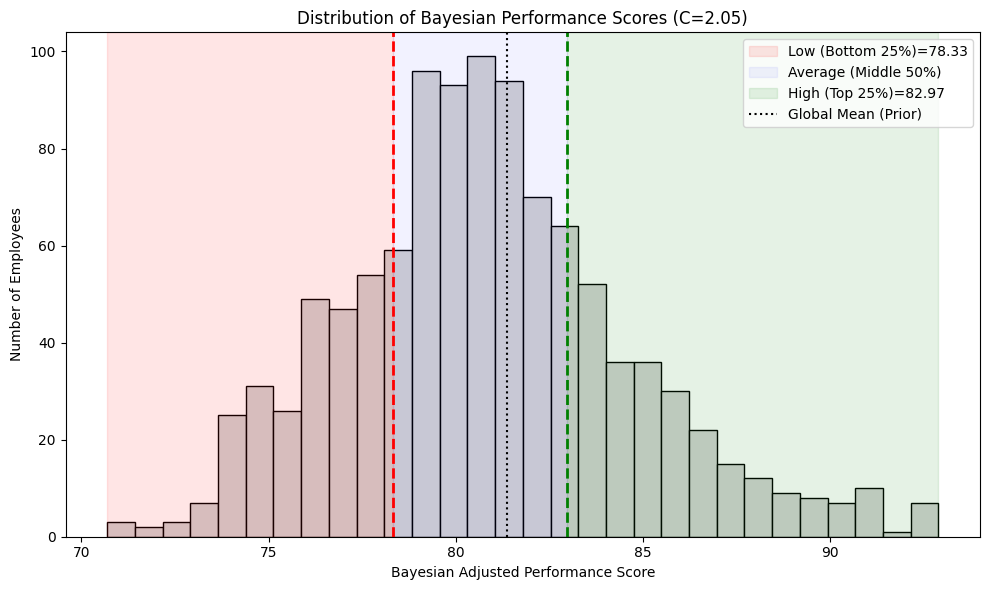

,EmployeeID,SimpleMean,ReviewCount,BayesianScore,PerformanceCategory
0,5000,78.300,1,80.359165,Average
1,5001,78.110,1,80.296901,Average
2,5002,95.750,1,86.077577,High
3,5003,89.894,5,87.411992,High
4,5004,89.210,1,83.934401,High


In [3]:
global_mean = performance['PerformanceScore'].mean()
reviews_per_employee = performance.groupby('EmployeeID').size()
C = reviews_per_employee.mean() # Your confidence constant = average number of reviews per employee

# 2. Calculate per-employee stats
employee_stats = performance.groupby('EmployeeID')['PerformanceScore'].agg(['mean', 'count']).reset_index()
employee_stats.columns = ['EmployeeID', 'SimpleMean', 'ReviewCount']

# 3. Apply Bayesian Average Formula
# Formula: (v*R + C*m) / (v + C)
def bayesian_avg(row):
    v = row['ReviewCount']
    R = row['SimpleMean']
    return (v * R + C * global_mean) / (v + C)

employee_stats['BayesianScore'] = employee_stats.apply(bayesian_avg, axis=1)

# 4. Calculate Thresholds based on Bayesian Scores
# Using your Q1/Q3 logic for Top 25%, Mid 50%, Bottom 25%
q1 = employee_stats['BayesianScore'].quantile(0.25)
q3 = employee_stats['BayesianScore'].quantile(0.75)

# 5. Categorize
conditions = [
    employee_stats['BayesianScore'] >= q3,
    employee_stats['BayesianScore'] < q1
]
choices = ['High', 'Low']
employee_stats['PerformanceCategory'] = np.select(conditions, choices, default='Average')

# 6. Plotting the Adjusted Distribution
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(employee_stats['BayesianScore'], bins=30, color='lightgray', edgecolor='black')

# Shade regions
plt.axvspan(employee_stats['BayesianScore'].min(), q1, color='red', alpha=0.1, label=f'Low (Bottom 25%)={q1:.2f}')
plt.axvspan(q1, q3, color='blue', alpha=0.05, label=f'Average (Middle 50%)')
plt.axvspan(q3, employee_stats['BayesianScore'].max(), color='green', alpha=0.1, label=f'High (Top 25%)={q3:.2f}')

# Vertical lines for the "Confidence Bar"
plt.axvline(q1, color='red', linestyle='dashed', linewidth=2)
plt.axvline(q3, color='green', linestyle='dashed', linewidth=2)
plt.axvline(global_mean, color='black', linestyle=':', label='Global Mean (Prior)')

plt.xlabel('Bayesian Adjusted Performance Score')
plt.ylabel('Number of Employees')
plt.title(f'Distribution of Bayesian Performance Scores (C={C:.2f})')
plt.legend()
plt.tight_layout()
plt.show()

employee_stats.head()